# Comparative Model Evaluation — Market Regime-Aware Stock Classification

Loads pre-trained baseline and tuned models directly — no retraining.

Covers:
- Stage 1 and Stage 2 full performance breakdown
- Per-class precision / recall / F1 analysis
- Statistical significance testing (McNemar's test)
- Regime-stratified Stage 2 performance
- Tuning analysis: why CV overestimated holdout
- Final model ranking and report-ready summary figure

In [7]:
import os, warnings, pickle
warnings.filterwarnings('ignore')
import logging
logging.getLogger('lightgbm').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2 as chi2_dist

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, precision_score, recall_score
)

SEED = 42
np.random.seed(SEED)

REGIME_NAMES = {0: 'Bullish', 1: 'Bearish', 2: 'High-Volatility'}
SIGNAL_NAMES = {0: 'Sell', 1: 'Hold', 2: 'Buy'}
MODEL_COLORS = {
    'Logistic Regression': '#3498db',
    'Random Forest': '#e67e22',
    'LightGBM': '#2ecc71'
}

os.makedirs('plots/evaluation', exist_ok=True)
os.makedirs('results', exist_ok=True)
print('Setup complete.')

Setup complete.


In [8]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# ── Baseline models ──
baseline = {
    's1': {
        'Logistic Regression': load_pkl('models/lr_s1.pkl'),
        'Random Forest': load_pkl('models/rf_s1.pkl'),
        'LightGBM': load_pkl('models/lgb_s1.pkl'),
    },
    's2': {
        'Logistic Regression': load_pkl('models/lr_s2.pkl'),
        'Random Forest': load_pkl('models/rf_s2.pkl'),
        'LightGBM': load_pkl('models/lgb_s2.pkl'),
    }
}
scaler_s1 = load_pkl('models/scaler_s1.pkl')
scaler_s2 = load_pkl('models/scaler_s2.pkl')
print('Baseline models loaded.')

# ── Tuned models (if available) ──
TUNED_AVAILABLE = os.path.exists('models/tuned/lgb_s1.pkl')
if TUNED_AVAILABLE:
    tuned = {
        's1': {
            'Logistic Regression': load_pkl('models/tuned/lr_s1.pkl'),
            'Random Forest': load_pkl('models/tuned/rf_s1.pkl'),
            'LightGBM': load_pkl('models/tuned/lgb_s1.pkl'),
        },
        's2': {
            'Logistic Regression': load_pkl('models/tuned/lr_s2.pkl'),
            'Random Forest': load_pkl('models/tuned/rf_s2.pkl'),
            'LightGBM': load_pkl('models/tuned/lgb_s2.pkl'),
        }
    }
    scaler_s1_t = load_pkl('models/tuned/scaler_s1.pkl')
    scaler_s2_t = load_pkl('models/tuned/scaler_s2.pkl')
    print('Tuned models loaded.')
else:
    print('Tuned models not found — tuning comparison will use saved CSV results.')

Baseline models loaded.
Tuned models loaded.


---
## 2. Reconstruct Test Sets

In [9]:
df = pd.read_csv('data/features/sp500_panel_with_features.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Encoded_Ticker', 'Date']).reset_index(drop=True)

S1_FEATURES = ['Ret_Lag1', 'Ret_Lag2', 'RSI', 'MACD_Norm',
                      'ATR_Pct', 'HL_range', 'Price_vs_SMA50',
                      'Momentum_Deviation', 'BB_Pct']
S2_FEATURES_BASE   = S1_FEATURES + ['Encoded_Ticker']
S2_FEATURES_REGIME = S2_FEATURES_BASE + ['regime_pred']

print(f'Loaded: {len(df):,} rows')

Loaded: 1,193,500 rows


In [10]:
# ── Stage 1 test set ──
WINDOW = 20
market_daily = (
    df.groupby('Date')['Ret_Lag1'].mean()
    .reset_index().rename(columns={'Ret_Lag1': 'market_return'})
    .sort_values('Date')
)
market_daily['rolling_ret'] = market_daily['market_return'].rolling(WINDOW).mean()
market_daily['rolling_vol'] = market_daily['market_return'].rolling(WINDOW).std()
market_daily.dropna(inplace=True)

ret_hi = market_daily['rolling_ret'].quantile(0.60)
ret_lo = market_daily['rolling_ret'].quantile(0.40)
vol_hi = market_daily['rolling_vol'].quantile(0.70)

def assign_regime(row):
    if row['rolling_vol'] >= vol_hi: return 2
    elif row['rolling_ret'] >= ret_hi: return 0
    elif row['rolling_ret'] <= ret_lo: return 1
    else: return 0

market_daily['regime'] = market_daily.apply(assign_regime, axis=1)

stage1_df = (
    df.groupby('Date')[S1_FEATURES].mean().reset_index().sort_values('Date')
    .merge(market_daily[['Date', 'regime']], on='Date', how='inner')
    .dropna().reset_index(drop=True)
)

split_date_s1 = stage1_df['Date'].quantile(0.8)
test_s1  = stage1_df[stage1_df['Date'] > split_date_s1]

X_test_s1 = scaler_s1.transform(test_s1[S1_FEATURES].values)
y_test_s1 = test_s1['regime'].values

print(f'Stage 1 test: {len(y_test_s1)} dates | split at {split_date_s1.date()}')

Stage 1 test: 489 dates | split at 2024-01-08


In [11]:
# ── Stage 2 test set ──
def label_signal(series):
    low, high = series.quantile(0.33), series.quantile(0.67)
    if low == high:
        m = series.median()
        return pd.Series(np.where(series < m, 0, np.where(series > m, 2, 1)), index=series.index)
    return pd.cut(series, bins=[-np.inf, low, high, np.inf], labels=[0, 1, 2])

df['signal'] = df.groupby('Encoded_Ticker')['y_return'].transform(label_signal).astype(int)

# regime_pred via the loaded baseline LightGBM S1
X_all_s1 = scaler_s1.transform(stage1_df[S1_FEATURES].values)
stage1_df['regime_pred'] = baseline['s1']['LightGBM'].predict(X_all_s1)
df = df.merge(stage1_df[['Date', 'regime_pred']], on='Date', how='left')
df['regime_pred'] = df['regime_pred'].ffill().bfill().astype(int)

df_s2 = df[S2_FEATURES_REGIME + ['Date', 'signal']].dropna().sort_values('Date').reset_index(drop=True)
split_date_s2 = df_s2['Date'].quantile(0.8)
test_s2 = df_s2[df_s2['Date'] > split_date_s2].reset_index(drop=True)

X_test_s2 = scaler_s2.transform(test_s2[S2_FEATURES_REGIME].values)
y_test_s2 = test_s2['signal'].values

print(f'Stage 2 test: {len(y_test_s2):,} rows | split at {split_date_s2.date()}')

Stage 2 test: 238,509 rows | split at 2024-01-23


In [12]:
preds_s1 = {name: m.predict(X_test_s1) for name, m in baseline['s1'].items()}
preds_s2 = {name: m.predict(X_test_s2) for name, m in baseline['s2'].items()}

if TUNED_AVAILABLE:
    X_test_s1_t = scaler_s1_t.transform(test_s1[S1_FEATURES].values)
    X_test_s2_t = scaler_s2_t.transform(test_s2[S2_FEATURES_REGIME].values)
    preds_s1_tuned = {name: m.predict(X_test_s1_t) for name, m in tuned['s1'].items()}
    preds_s2_tuned = {name: m.predict(X_test_s2_t) for name, m in tuned['s2'].items()}

print('Predictions ready.')
print('\nStage 1 Macro F1:')
for name, yp in preds_s1.items():
    print(f'  {name}: {f1_score(y_test_s1, yp, average="macro"):.4f}')
print('\nStage 2 Macro F1:')
for name, yp in preds_s2.items():
    print(f'  {name}: {f1_score(y_test_s2, yp, average="macro"):.4f}')

Predictions ready.

Stage 1 Macro F1:
  Logistic Regression: 0.6041
  Random Forest: 0.6315
  LightGBM: 0.6690

Stage 2 Macro F1:
  Logistic Regression: 0.3377
  Random Forest: 0.3488
  LightGBM: 0.3522


---
## 4. Stage 1 Evaluation

In [13]:
s1_summary = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': accuracy_score(y_test_s1, yp),
        'Macro F1': f1_score(y_test_s1, yp, average='macro'),
        'Weighted F1': f1_score(y_test_s1, yp, average='weighted'),
        'Macro Prec':  precision_score(y_test_s1, yp, average='macro'),
        'Macro Rec': recall_score(y_test_s1, yp, average='macro'),
    }
    for name, yp in preds_s1.items()
]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('=== Stage 1 Summary ===')
print(s1_summary.to_string(index=False))

# Per-class
per_class_s1 = []
for name, yp in preds_s1.items():
    rpt = classification_report(y_test_s1, yp, output_dict=True)
    for k, v in REGIME_NAMES.items():
        per_class_s1.append({'Model': name, 'Class': v,
                              'Precision': rpt[str(k)]['precision'],
                              'Recall': rpt[str(k)]['recall'],
                              'F1': rpt[str(k)]['f1-score'],
                              'Support': int(rpt[str(k)]['support'])})
per_class_s1_df = pd.DataFrame(per_class_s1)
print('\n=== Stage 1 Per-Class ===')
print(per_class_s1_df.to_string(index=False))

=== Stage 1 Summary ===
              Model  Accuracy  Macro F1  Weighted F1  Macro Prec  Macro Rec
           LightGBM  0.697342  0.669021     0.707043    0.669465   0.696434
      Random Forest  0.660532  0.631521     0.673364    0.642619   0.663678
Logistic Regression  0.627812  0.604088     0.651539    0.635696   0.640745

=== Stage 1 Per-Class ===
              Model           Class  Precision   Recall       F1  Support
Logistic Regression         Bullish   0.820513 0.645161 0.722348      248
Logistic Regression         Bearish   0.762712 0.555556 0.642857      162
Logistic Regression High-Volatility   0.323864 0.721519 0.447059       79
      Random Forest         Bullish   0.798165 0.701613 0.746781      248
      Random Forest         Bearish   0.741935 0.567901 0.643357      162
      Random Forest High-Volatility   0.387755 0.721519 0.504425       79
           LightGBM         Bullish   0.810811 0.725806 0.765957      248
           LightGBM         Bearish   0.759124 0.6419

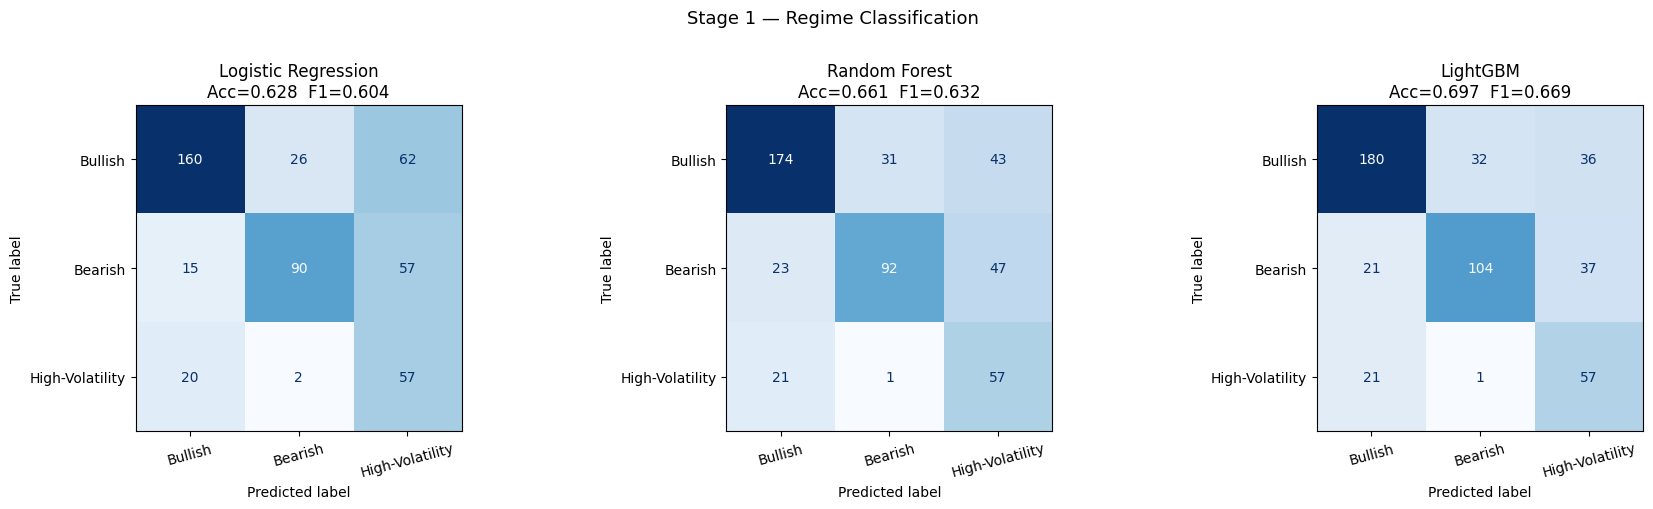

In [14]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp) in zip(axes, preds_s1.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test_s1, yp),
                           display_labels=list(REGIME_NAMES.values())
                           ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc={accuracy_score(y_test_s1, yp):.3f}  '
                 f'F1={f1_score(y_test_s1, yp, average="macro"):.3f}')
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Stage 1 — Regime Classification', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plots/evaluation/s1_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

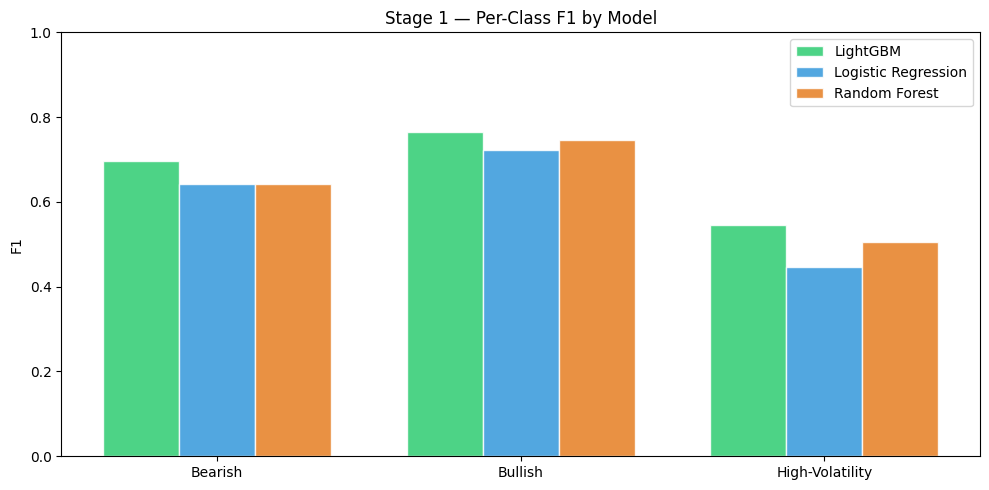

In [15]:
# Per-class F1 grouped bar
pivot_s1 = per_class_s1_df.pivot(index='Class', columns='Model', values='F1')
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(pivot_s1)), 0.25
for i, model in enumerate(pivot_s1.columns):
    ax.bar(x + i*w, pivot_s1[model], w, label=model,
           color=MODEL_COLORS[model], alpha=0.85, edgecolor='white')
ax.set_xticks(x + w); ax.set_xticklabels(pivot_s1.index)
ax.set_ylabel('F1'); ax.set_title('Stage 1 — Per-Class F1 by Model')
ax.legend(); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('plots/evaluation/s1_perclass_f1.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Stage 2 Evaluation

In [16]:
s2_summary = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': accuracy_score(y_test_s2, yp),
        'Macro F1': f1_score(y_test_s2, yp, average='macro'),
        'Weighted F1': f1_score(y_test_s2, yp, average='weighted'),
        'Macro Prec':  precision_score(y_test_s2, yp, average='macro'),
        'Macro Rec': recall_score(y_test_s2, yp, average='macro'),
    }
    for name, yp in preds_s2.items()
]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('=== Stage 2 Summary ===')
print(s2_summary.to_string(index=False))

# Per-class
per_class_s2 = []
for name, yp in preds_s2.items():
    rpt = classification_report(y_test_s2, yp, output_dict=True)
    for k, v in SIGNAL_NAMES.items():
        per_class_s2.append({'Model': name, 'Class': v,
                              'Precision': rpt[str(k)]['precision'],
                              'Recall': rpt[str(k)]['recall'],
                              'F1': rpt[str(k)]['f1-score'],
                              'Support': int(rpt[str(k)]['support'])})
per_class_s2_df = pd.DataFrame(per_class_s2)
print('\n=== Stage 2 Per-Class ===')
print(per_class_s2_df.to_string(index=False))

=== Stage 2 Summary ===
              Model  Accuracy  Macro F1  Weighted F1  Macro Prec  Macro Rec
           LightGBM  0.363391  0.352195     0.352366    0.361470   0.362965
      Random Forest  0.363123  0.348759     0.348951    0.361058   0.362627
Logistic Regression  0.360213  0.337666     0.337793    0.356553   0.359845

=== Stage 2 Per-Class ===
              Model Class  Precision   Recall       F1  Support
Logistic Regression  Sell   0.344752 0.143574 0.202722    79562
Logistic Regression  Hold   0.363789 0.554977 0.439491    80088
Logistic Regression   Buy   0.361119 0.380984 0.370785    78859
      Random Forest  Sell   0.349326 0.202245 0.256175    79562
      Random Forest  Hold   0.364970 0.550632 0.438977    80088
      Random Forest   Buy   0.368879 0.335003 0.351126    78859
           LightGBM  Sell   0.350585 0.219665 0.270097    79562
           LightGBM  Hold   0.366294 0.527657 0.432412    80088
           LightGBM   Buy   0.367531 0.341572 0.354076    78859


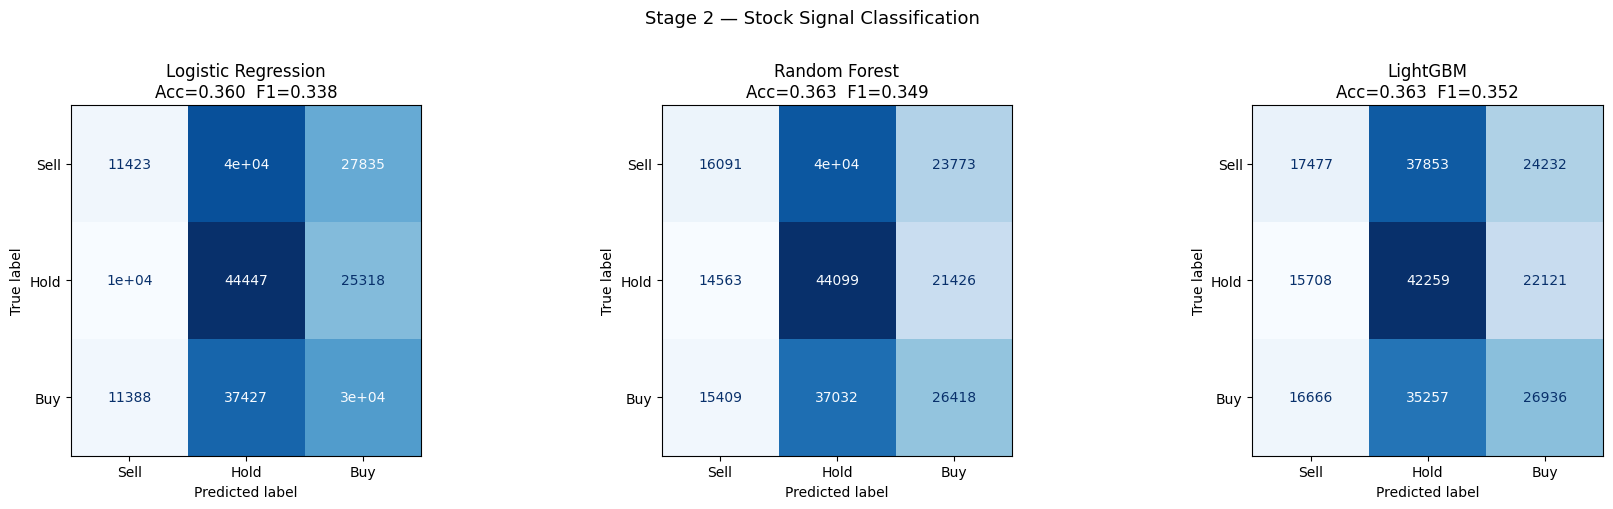

In [17]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp) in zip(axes, preds_s2.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test_s2, yp),
                           display_labels=list(SIGNAL_NAMES.values())
                           ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc={accuracy_score(y_test_s2, yp):.3f}  '
                 f'F1={f1_score(y_test_s2, yp, average="macro"):.3f}')
plt.suptitle('Stage 2 — Stock Signal Classification', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('plots/evaluation/s2_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

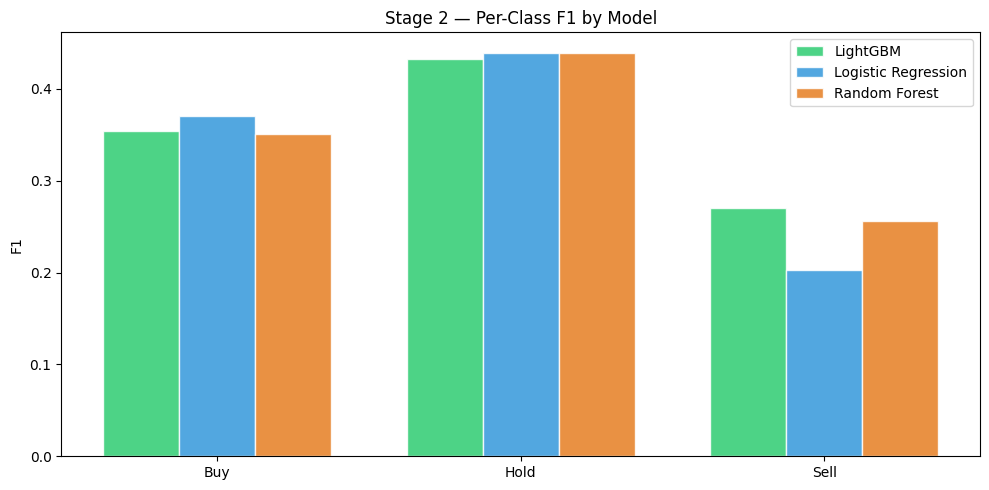

In [18]:
# Per-class F1 grouped bar
pivot_s2 = per_class_s2_df.pivot(index='Class', columns='Model', values='F1')
fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(pivot_s2)), 0.25
for i, model in enumerate(pivot_s2.columns):
    ax.bar(x + i*w, pivot_s2[model], w, label=model,
           color=MODEL_COLORS[model], alpha=0.85, edgecolor='white')
ax.set_xticks(x + w); ax.set_xticklabels(pivot_s2.index)
ax.set_ylabel('F1'); ax.set_title('Stage 2 — Per-Class F1 by Model')
ax.legend()
plt.tight_layout()
plt.savefig('plots/evaluation/s2_perclass_f1.png', dpi=150, bbox_inches='tight')
plt.show()

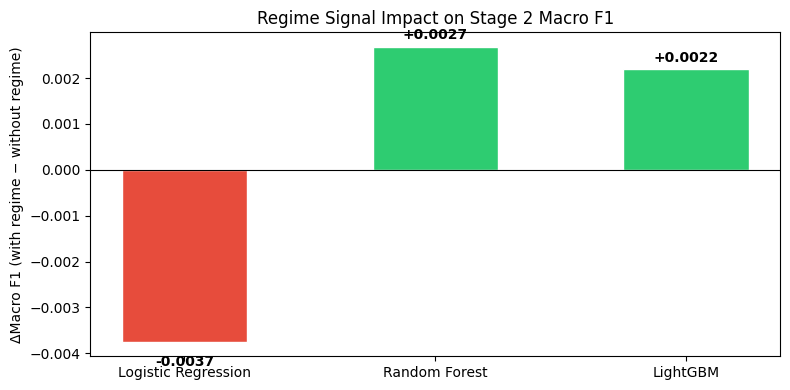

In [19]:
# Regime delta — load from saved CSV (computed in ModelTraining)
delta_df = pd.read_csv('results/regime_impact.csv')
delta_df.columns = ['Model', 'Delta']

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in delta_df['Delta']]
ax.bar(delta_df['Model'], delta_df['Delta'], color=colors, edgecolor='white', width=0.5)
ax.axhline(0, color='black', lw=0.8)
for i, row in delta_df.iterrows():
    offset = 0.0001 if row['Delta'] > 0 else -0.0003
    ax.text(i, row['Delta'] + offset, f"{row['Delta']:+.4f}",
            ha='center', va='bottom' if row['Delta'] > 0 else 'top',
            fontsize=10, fontweight='bold')
ax.set_ylabel('ΔMacro F1 (with regime − without regime)')
ax.set_title('Regime Signal Impact on Stage 2 Macro F1')
plt.tight_layout()
plt.savefig('plots/evaluation/regime_delta.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Statistical Significance — McNemar's Test

In [20]:
def mcnemar_test(y_true, pred_a, pred_b):
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    b = np.sum(~correct_a &  correct_b)
    c = np.sum( correct_a & ~correct_b)
    if (b + c) == 0:
        return 0.0, 1.0
    chi2 = (abs(b - c) - 1) ** 2 / (b + c)
    p = 1 - chi2_dist.cdf(chi2, df=1)
    return round(chi2, 3), round(p, 5)

model_names = list(preds_s1.keys())

print('=== Stage 1 — McNemar Pairwise Tests ===')
s1_mcnemar = []
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        a, b = model_names[i], model_names[j]
        chi2, p = mcnemar_test(y_test_s1, preds_s1[a], preds_s1[b])
        sig = 'Significant' if p < 0.05 else 'Not significant'
        s1_mcnemar.append({'Model A': a, 'Model B': b, 'chi2': chi2, 'p-value': p, 'Result': sig})
        print(f'  {a} vs {b}: chi2={chi2}, p={p} -> {sig}')

print('\n=== Stage 2 — McNemar Pairwise Tests ===')
s2_mcnemar = []
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        a, b = model_names[i], model_names[j]
        chi2, p = mcnemar_test(y_test_s2, preds_s2[a], preds_s2[b])
        sig = 'Significant' if p < 0.05 else 'Not significant'
        s2_mcnemar.append({'Model A': a, 'Model B': b, 'chi2': chi2, 'p-value': p, 'Result': sig})
        print(f'  {a} vs {b}: chi2={chi2}, p={p} -> {sig}')

s1_mcnemar_df = pd.DataFrame(s1_mcnemar)
s2_mcnemar_df = pd.DataFrame(s2_mcnemar)

=== Stage 1 — McNemar Pairwise Tests ===
  Logistic Regression vs Random Forest: chi2=5.357, p=0.02064 -> Significant
  Logistic Regression vs LightGBM: chi2=21.78, p=0.0 -> Significant
  Random Forest vs LightGBM: chi2=8.5, p=0.00355 -> Significant

=== Stage 2 — McNemar Pairwise Tests ===
  Logistic Regression vs Random Forest: chi2=19.161, p=1e-05 -> Significant
  Logistic Regression vs LightGBM: chi2=19.387, p=1e-05 -> Significant
  Random Forest vs LightGBM: chi2=0.225, p=0.63562 -> Not significant


---
## 7. Regime-Stratified Stage 2 Performance

=== Regime-Stratified Performance ===
         Regime               Model      N  Macro F1  Accuracy
        Bullish Logistic Regression 106027  0.263965  0.362559
        Bullish       Random Forest 106027  0.277306  0.360927
        Bullish            LightGBM 106027  0.278594  0.362559
        Bearish Logistic Regression  67710  0.331971  0.348117
        Bearish       Random Forest  67710  0.334343  0.355295
        Bearish            LightGBM  67710  0.332218  0.352754
High-Volatility Logistic Regression  64772  0.274745  0.369017
High-Volatility       Random Forest  64772  0.310914  0.374900
High-Volatility            LightGBM  64772  0.321229  0.375872


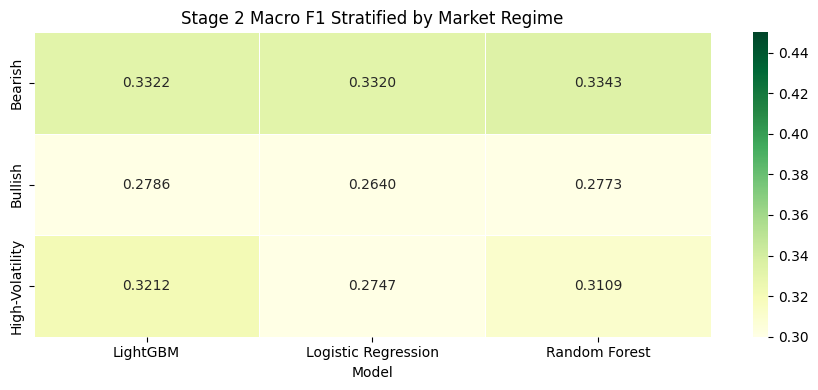

In [21]:
strat_rows = []
for regime_id, regime_name in REGIME_NAMES.items():
    mask = test_s2['regime_pred'].values == regime_id
    if mask.sum() < 100:
        continue
    y_sub = y_test_s2[mask]
    for name, yp in preds_s2.items():
        strat_rows.append({
            'Regime': regime_name,
            'Model': name,
            'N': int(mask.sum()),
            'Macro F1': f1_score(y_sub, yp[mask], average='macro', zero_division=0),
            'Accuracy': accuracy_score(y_sub, yp[mask]),
        })

strat_df = pd.DataFrame(strat_rows)
print('=== Regime-Stratified Performance ===')
print(strat_df.to_string(index=False))

pivot_strat = strat_df.pivot(index='Regime', columns='Model', values='Macro F1')
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot_strat, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, ax=ax, vmin=0.30, vmax=0.45)
ax.set_title('Stage 2 Macro F1 Stratified by Market Regime')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('plots/evaluation/regime_stratified_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Tuning Analysis — CV vs Holdout Gap

=== Stage 1: Baseline vs Optuna CV vs Tuned Holdout ===
              Model  Baseline Macro F1  Optuna CV F1  Tuned Macro F1     Delta
Logistic Regression             0.6041        0.7459        0.595100 -0.009000
      Random Forest             0.6315        0.7694        0.630421 -0.001079
           LightGBM             0.6690        0.7702        0.658137 -0.010863

=== Stage 2: Baseline vs Optuna CV vs Tuned Holdout ===
              Model  Baseline Macro F1  Optuna CV F1  Tuned Macro F1     Delta
Logistic Regression             0.3377        0.3615        0.336104 -0.001596
      Random Forest             0.3491        0.3873        0.349062 -0.000038
           LightGBM             0.3523        0.3660        0.351635 -0.000665


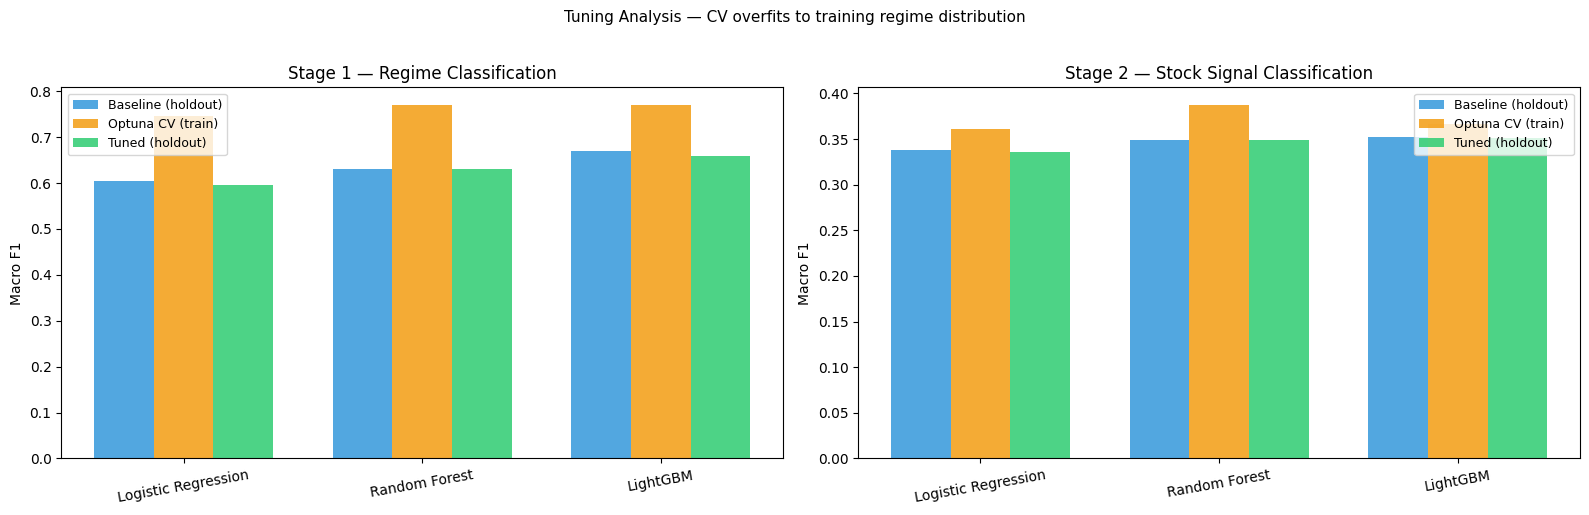

In [22]:
tuning_s1 = pd.read_csv('results/tuning_comparison_s1.csv')
tuning_s2 = pd.read_csv('results/tuning_comparison_s2.csv')

# Optuna best CV scores from optimization history plots
optuna_cv_s1 = {'Logistic Regression': 0.7459, 'Random Forest': 0.7694, 'LightGBM': 0.7702}
optuna_cv_s2 = {'Logistic Regression': 0.3615, 'Random Forest': 0.3873, 'LightGBM': 0.3660}
tuning_s1['Optuna CV F1'] = tuning_s1['Model'].map(optuna_cv_s1)
tuning_s2['Optuna CV F1'] = tuning_s2['Model'].map(optuna_cv_s2)

print('=== Stage 1: Baseline vs Optuna CV vs Tuned Holdout ===')
print(tuning_s1[['Model', 'Baseline Macro F1', 'Optuna CV F1', 'Tuned Macro F1', 'Delta']].to_string(index=False))
print()
print('=== Stage 2: Baseline vs Optuna CV vs Tuned Holdout ===')
print(tuning_s2[['Model', 'Baseline Macro F1', 'Optuna CV F1', 'Tuned Macro F1', 'Delta']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (df_t, title) in zip(axes, [
    (tuning_s1, 'Stage 1 — Regime Classification'),
    (tuning_s2, 'Stage 2 — Stock Signal Classification')
]):
    x, w = np.arange(len(df_t)), 0.25
    ax.bar(x - w, df_t['Baseline Macro F1'], w, label='Baseline (holdout)', color='#3498db', alpha=0.85)
    ax.bar(x,     df_t['Optuna CV F1'], w, label='Optuna CV (train)', color='#f39c12', alpha=0.85)
    ax.bar(x + w, df_t['Tuned Macro F1'], w, label='Tuned (holdout)', color='#2ecc71', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(df_t['Model'], rotation=10)
    ax.set_ylabel('Macro F1'); ax.set_title(title); ax.legend(fontsize=9)
plt.suptitle('Tuning Analysis — CV overfits to training regime distribution', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('plots/evaluation/tuning_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Report Summary Figure

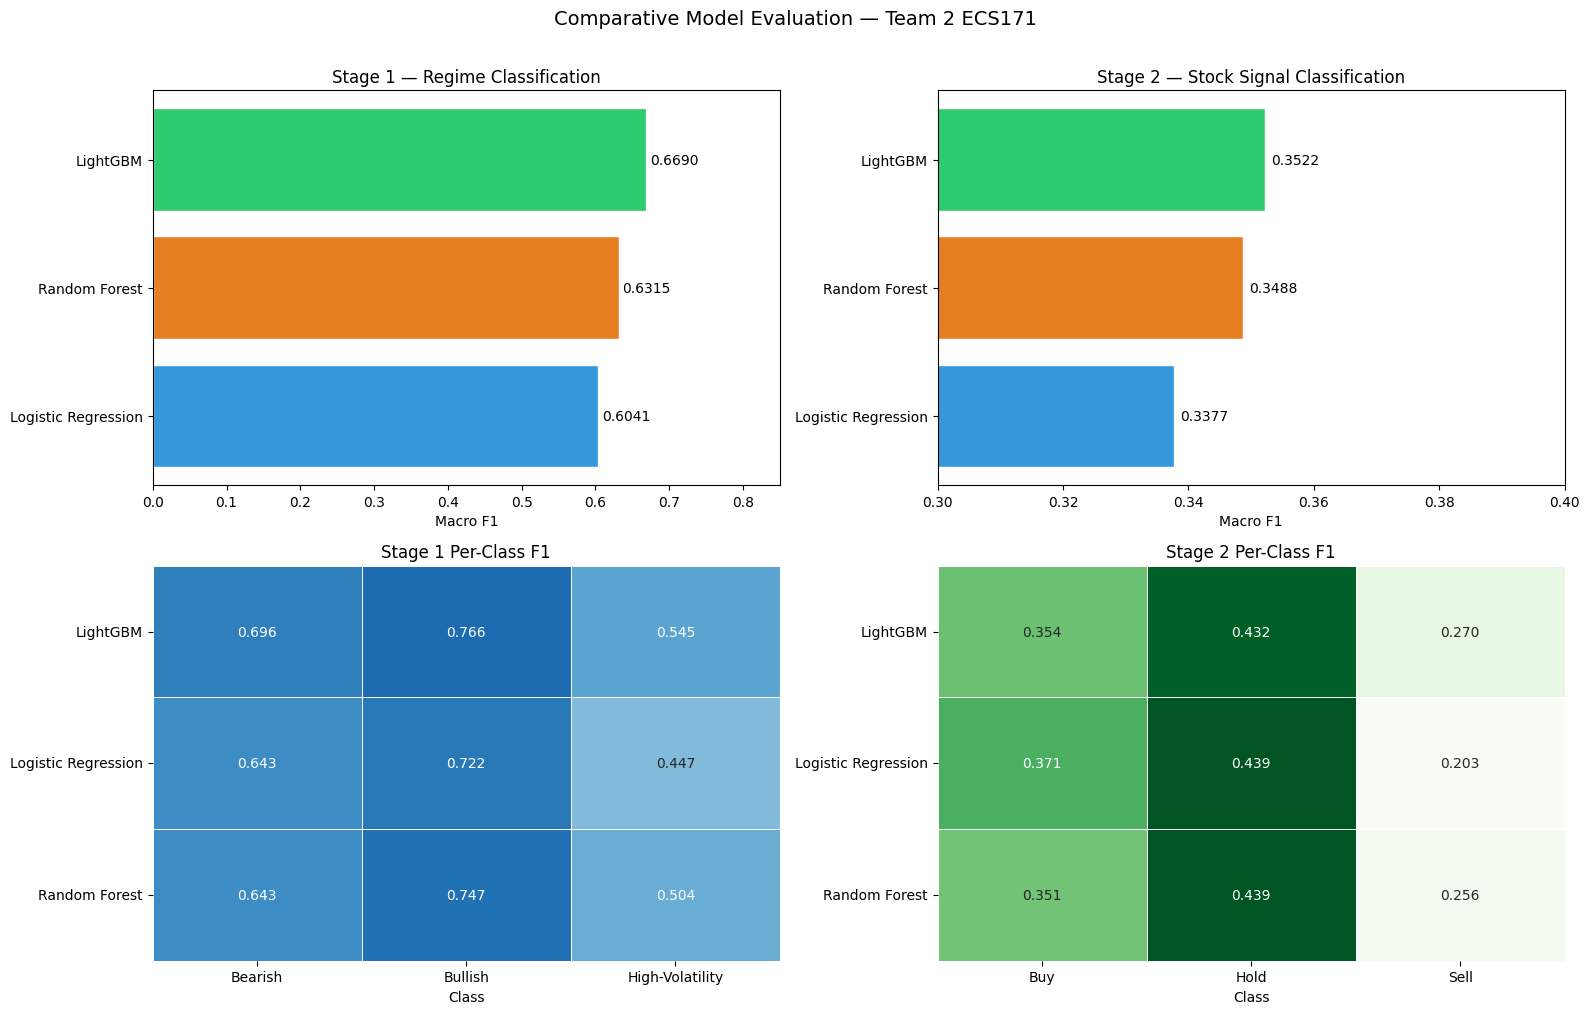

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: Stage 1 Macro F1
ax = axes[0, 0]
d = s1_summary.sort_values('Macro F1')
bars = ax.barh(d['Model'], d['Macro F1'],
               color=[MODEL_COLORS[m] for m in d['Model']], edgecolor='white')
for bar, val in zip(bars, d['Macro F1']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Macro F1'); ax.set_title('Stage 1 — Regime Classification'); ax.set_xlim(0, 0.85)

# Top-right: Stage 2 Macro F1
ax = axes[0, 1]
d = s2_summary.sort_values('Macro F1')
bars = ax.barh(d['Model'], d['Macro F1'],
               color=[MODEL_COLORS[m] for m in d['Model']], edgecolor='white')
for bar, val in zip(bars, d['Macro F1']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Macro F1'); ax.set_title('Stage 2 — Stock Signal Classification'); ax.set_xlim(0.30, 0.40)

# Bottom-left: Stage 1 per-class F1 heatmap
ax = axes[1, 0]
sns.heatmap(per_class_s1_df.pivot(index='Model', columns='Class', values='F1'),
            annot=True, fmt='.3f', cmap='Blues', linewidths=0.5,
            ax=ax, vmin=0, vmax=1, cbar=False)
ax.set_title('Stage 1 Per-Class F1'); ax.set_ylabel('')

# Bottom-right: Stage 2 per-class F1 heatmap
ax = axes[1, 1]
sns.heatmap(per_class_s2_df.pivot(index='Model', columns='Class', values='F1'),
            annot=True, fmt='.3f', cmap='Greens', linewidths=0.5,
            ax=ax, vmin=0.25, vmax=0.45, cbar=False)
ax.set_title('Stage 2 Per-Class F1'); ax.set_ylabel('')

plt.suptitle('Comparative Model Evaluation — Team 2 ECS171', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/evaluation/report_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Save All Results

In [24]:
s1_summary.to_csv('results/eval_s1_summary.csv', index=False)
s2_summary.to_csv('results/eval_s2_summary.csv', index=False)
per_class_s1_df.to_csv('results/eval_s1_perclass.csv', index=False)
per_class_s2_df.to_csv('results/eval_s2_perclass.csv', index=False)
strat_df.to_csv('results/eval_regime_stratified.csv', index=False)
s1_mcnemar_df.to_csv('results/eval_mcnemar_s1.csv', index=False)
s2_mcnemar_df.to_csv('results/eval_mcnemar_s2.csv', index=False)

print('All results saved.')
print()
print('=== KEY FINDINGS ===')
print(f'Best Stage 1: {s1_summary.iloc[0]["Model"]} — Macro F1 = {s1_summary.iloc[0]["Macro F1"]:.4f}')
print(f'Best Stage 2: {s2_summary.iloc[0]["Model"]} — Macro F1 = {s2_summary.iloc[0]["Macro F1"]:.4f}')
print(f'Regime lift: RF +0.0027, LightGBM +0.0022, LR -0.0037')
print(f'Tuning: all models negative delta on holdout — regime-drift confirmed')
print()
print('McNemar Stage 1:')
print(s1_mcnemar_df[['Model A', 'Model B', 'p-value', 'Result']].to_string(index=False))
print('\nMcNemar Stage 2:')
print(s2_mcnemar_df[['Model A', 'Model B', 'p-value', 'Result']].to_string(index=False))

All results saved.

=== KEY FINDINGS ===
Best Stage 1: LightGBM — Macro F1 = 0.6690
Best Stage 2: LightGBM — Macro F1 = 0.3522
Regime lift: RF +0.0027, LightGBM +0.0022, LR -0.0037
Tuning: all models negative delta on holdout — regime-drift confirmed

McNemar Stage 1:
            Model A       Model B  p-value      Result
Logistic Regression Random Forest  0.02064 Significant
Logistic Regression      LightGBM  0.00000 Significant
      Random Forest      LightGBM  0.00355 Significant

McNemar Stage 2:
            Model A       Model B  p-value          Result
Logistic Regression Random Forest  0.00001     Significant
Logistic Regression      LightGBM  0.00001     Significant
      Random Forest      LightGBM  0.63562 Not significant
